# Deteksi Anomali Makroekonomi - Autoencoder (REVISI)

**Early Warning System Krisis Ekonomi | Kelompok 4 - 3SI1**

**Metode:** Autoencoder (Deep Learning) - *Semi-supervised Novelty Detection*

**Disusun oleh:** Deka

---

## Ringkasan Revisi

Notebook ini adalah **revisi total** dari versi sebelumnya. Perbaikan yang diterapkan:

| No | Masalah pada Versi Lama | Perbaikan di Notebook Ini |
|----|-------------------------|---------------------------|
| 1 | `Exchange_Rate` nominal LCU/USD (VND 24.000 vs GBP 0,8) | Diganti `Exchange_Depreciation` (% perubahan YoY per negara) |
| 2 | `Total_Reserves` nominal USD (USD 3,9T vs USD 79jt) | Diganti `Reserves_Months_Imports` (rasio, sudah ada di master) |
| 3 | `crisis_label` dibuat sendiri dari 4 variabel input (tautologi) | Ground truth eksternal IMF Laeven & Valencia |
| 4 | Bias struktural: Singapura/Irlandia dicap anomali 35 tahun | *Country demeaning* sebelum standardisasi global |
| 5 | Model *coincident*, bukan *early warning* | Evaluasi ganda: konkuren (t) dan *lead* (t-1, t-2) |
| 6 | Klaim "unsupervised" padahal memakai label | Disebut jujur: *semi-supervised novelty detection* |
| 7 | Threshold P92 dihitung dari seluruh data | Threshold dikalibrasi pada data latih normal saja |
| 8 | Imputasi global (mencampur antar negara) | Interpolasi linear per negara, urut waktu |

**Catatan kejujuran metodologis:** Autoencoder di sini **bukan** *unsupervised* murni. Model dilatih hanya pada data non-krisis, sehingga tepatnya disebut **semi-supervised novelty detection**. Hal ini dinyatakan eksplisit agar konsisten dengan klaim pada Bab I laporan.

## 1. Setup dan Import Library

In [1]:
# Di Google Colab, TensorFlow sudah terpasang secara default.
import sys
print("Python:", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_curve, auc, roc_auc_score,
                             precision_recall_curve, average_precision_score)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Reproducibility: WAJIB seed 42 (standar kelompok)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

Python: 3.13.15
TensorFlow: 2.20.0


## 2. Load Data Mentah dan Ground Truth

Dua file input sesuai standar kelompok:

- **raw_data_master.csv** berisi 1.715 baris data mentah, 49 negara kali 35 tahun, periode 1990 sampai 2024.
- **ground_truth_imf.csv** berisi label krisis eksternal dari IMF Laeven dan Valencia (2018).

Ground truth **tidak diturunkan dari variabel input**, sehingga tidak terjadi tautologi.

In [2]:
import os

RAW_PATH = 'raw_data_master.csv'
GT_PATH  = 'ground_truth_imf.csv'

# Di Colab: jika file belum ada, munculkan dialog upload secara otomatis.
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not (os.path.exists(RAW_PATH) and os.path.exists(GT_PATH)):
    print("Silakan upload raw_data_master.csv dan ground_truth_imf.csv")
    from google.colab import files
    files.upload()

for _p in (RAW_PATH, GT_PATH):
    if not os.path.exists(_p):
        raise FileNotFoundError(
            f"File '{_p}' tidak ditemukan. Upload file tersebut ke sesi ini "
            "(ikon folder di panel kiri Colab), lalu jalankan ulang sel ini.")

df_raw = pd.read_csv(RAW_PATH)
df_gt  = pd.read_csv(GT_PATH)

print("Raw data    :", df_raw.shape)
print("Ground truth:", df_gt.shape)
print("Negara      :", df_raw['economy'].nunique())
print("Periode     :", df_raw['year'].min(), "-", df_raw['year'].max())

# Validasi standar kelompok: tepat 1.715 baris, tanpa drop
assert len(df_raw) == 1715, f"Jumlah baris harus 1715, ditemukan {len(df_raw)}"
assert df_raw.groupby('economy').size().nunique() == 1, "Panel tidak seimbang"
print("\n[OK] Panel seimbang: 49 negara x 35 tahun = 1.715 observasi")

df_raw.head()

Raw data    : (1715, 16)
Ground truth: (1715, 7)
Negara      : 49
Periode     : 1990 - 2024

[OK] Panel seimbang: 49 negara x 35 tahun = 1.715 observasi


,economy,year,GDP_Growth,Inflation_CPI,Unemployment,Current_Account_GDP,Reserves_Months_Imports,Exchange_Rate,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Investment_GDP,Manufacturing_Value,Domestic_Credit_GDP,Broad_Money_Growth
0,ARE,1990,18.327723,NaN,NaN,NaN,NaN,3.671,-0.228436,NaN,NaN,NaN,NaN,7.494109,NaN,-8.197759
1,ARE,1991,0.860104,NaN,1.629,NaN,NaN,3.671,0.050318,NaN,NaN,NaN,NaN,7.422869,NaN,14.542822
2,ARE,1992,3.345282,NaN,1.715,NaN,NaN,3.671,0.239163,NaN,NaN,NaN,NaN,7.583716,NaN,4.615917
3,ARE,1993,1.261098,NaN,1.901,NaN,NaN,3.671,0.721471,NaN,NaN,NaN,NaN,7.843977,NaN,-1.576729
4,ARE,1994,6.896076,NaN,1.834,NaN,NaN,3.671,0.105320,NaN,NaN,NaN,NaN,9.471981,NaN,7.897391


Persentase missing value per kolom:
Broad_Money_Growth         25.01
Domestic_Credit_GDP        18.60
Gross_Savings_GDP           9.33
Manufacturing_Value         6.76
Reserves_Months_Imports     6.59
Current_Account_GDP         6.59
Investment_GDP              3.67
Inflation_CPI               3.38
Imports_GDP                 3.38
Exports_GDP                 3.38
Unemployment                2.86
Exchange_Rate               0.52
FDI_Inflows_GDP             0.29
GDP_Growth                  0.17


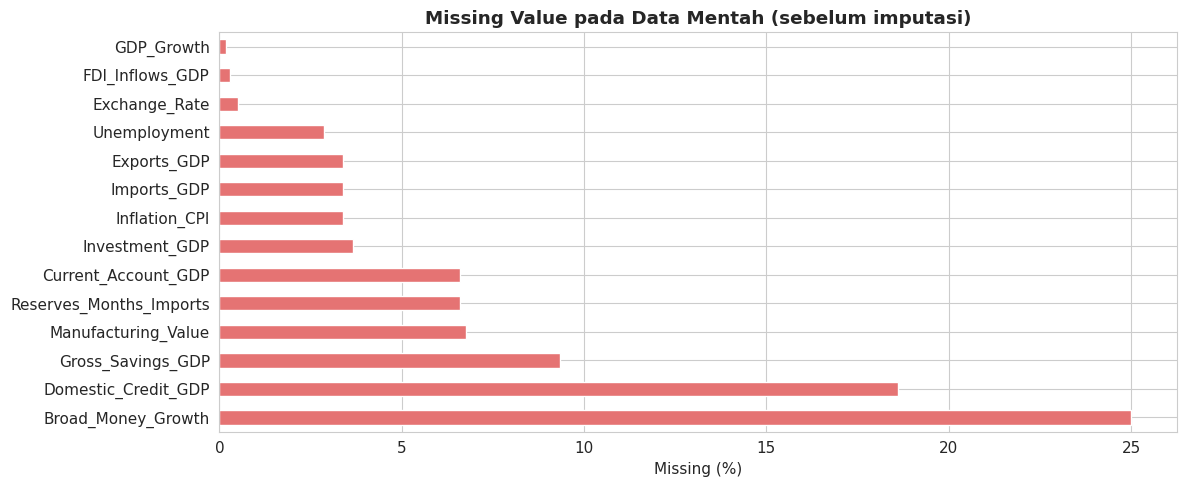

In [3]:
# Missing value pada data mentah
miss = (df_raw.isna().mean()*100).round(2).sort_values(ascending=False)
print("Persentase missing value per kolom:")
print(miss[miss > 0].to_string())

fig, ax = plt.subplots(figsize=(12,5))
miss[miss>0].plot(kind='barh', ax=ax, color='#e57373')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value pada Data Mentah (sebelum imputasi)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Feature Engineering (Standar Wajib Kelompok)

### 3.1 Nilai Tukar menjadi Persentase Depresiasi

Ini perbaikan paling kritis. Nilai tukar nominal LCU per USD tidak dapat dibandingkan lintas negara:

| Negara | Nilai Nominal | Makna Sebenarnya |
|--------|---------------|------------------|
| Vietnam (VND) | sekitar 24.000 per USD | Normal dan stabil |
| Indonesia (IDR) | sekitar 15.000 per USD | Normal |
| Inggris (GBP) | sekitar 0,8 per USD | Normal |

Jika distandarisasi secara global, Vietnam memperoleh z-score ekstrem dan dicap krisis permanen, padahal nilainya stabil. Yang bermakna sebagai sinyal krisis mata uang adalah **laju depresiasi**, bukan level nominalnya.

In [4]:
# WAJIB: urutkan dulu agar pct_change valid secara temporal
df = df_raw.sort_values(['economy', 'year']).reset_index(drop=True)

# Bukti masalah: sebaran nilai tukar nominal antar negara
er_med = df.groupby('economy')['Exchange_Rate'].median().sort_values()
print("Nilai tukar nominal (median) - 4 terendah vs 4 tertinggi:")
print(pd.concat([er_med.head(4), er_med.tail(4)]).round(2).to_string())
print(f"\nRasio ekstrem: {er_med.max()/er_med.min():,.0f}x")

# Transformasi: persentase depresiasi tahunan per negara
df['Exchange_Depreciation'] = df.groupby('economy')['Exchange_Rate'].pct_change() * 100

# Tahun pertama (1990) tidak punya t-1, diisi 0
df['Exchange_Depreciation'] = df['Exchange_Depreciation'].fillna(0)

# Hapus kolom nominal asli
df = df.drop(columns=['Exchange_Rate'])

print("\n[OK] Exchange_Rate (nominal) diganti Exchange_Depreciation (persen)")
print(df['Exchange_Depreciation'].describe().round(2).to_string())

Nilai tukar nominal (median) - 4 terendah vs 4 tertinggi:
economy
GBR        0.64
IRL        0.80
AUT        0.90
BEL        0.90
KOR     1130.36
COL     2087.92
IDN     9386.63
VNM    16105.12

Rasio ekstrem: 25,127x

[OK] Exchange_Rate (nominal) diganti Exchange_Depreciation (persen)
count    1715.00
mean        8.25
std        70.28
min       -99.95
25%        -2.02
50%         0.68
75%         7.08
max      1859.86


### 3.2 Imputasi Missing Value (Per Negara, Urut Waktu)

Interpolasi dilakukan **per negara** agar tren waktu masing-masing negara terjaga. Imputasi global akan mencampur level ekonomi Jepang dengan Kenya.

In [5]:
FEATURE_COLS = [c for c in df.columns if c not in ('economy', 'year')]
print(f"Jumlah fitur: {len(FEATURE_COLS)}")
for i, c in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {c}")

n_before = int(df[FEATURE_COLS].isna().sum().sum())

# Langkah 1: interpolasi linear per negara (menjaga tren temporal)
for col in FEATURE_COLS:
    df[col] = df.groupby('economy')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both'))

# Langkah 2: sisa NaN (negara yang kosong total) diisi median per negara
for col in FEATURE_COLS:
    df[col] = df.groupby('economy')[col].transform(lambda x: x.fillna(x.median()))

# Langkah 3: pengaman terakhir, median global
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

n_after = int(df[FEATURE_COLS].isna().sum().sum())
print(f"\nMissing sebelum: {n_before}  menjadi: {n_after}")
assert n_after == 0 and len(df) == 1715
print("[OK] Imputasi selesai, 1.715 baris utuh tanpa drop")

Jumlah fitur: 14
   1. GDP_Growth
   2. Inflation_CPI
   3. Unemployment
   4. Current_Account_GDP
   5. Reserves_Months_Imports
   6. FDI_Inflows_GDP
   7. Exports_GDP
   8. Imports_GDP
   9. Gross_Savings_GDP
  10. Investment_GDP
  11. Manufacturing_Value
  12. Domestic_Credit_GDP
  13. Broad_Money_Growth
  14. Exchange_Depreciation

Missing sebelum: 1544  menjadi: 0
[OK] Imputasi selesai, 1.715 baris utuh tanpa drop


## 4. Penggabungan Ground Truth Eksternal

Label krisis berasal dari IMF Laeven dan Valencia (2018), bukan dibuat dari variabel input. Ini menghilangkan *circular reasoning* yang ada pada versi lama.

In [6]:
data = df.merge(df_gt[['economy','year','is_crisis','crisis_name',
                        'banking_crisis','currency_crisis','sovereign_debt_crisis']],
                on=['economy','year'], how='left')

assert len(data) == 1715 and data['is_crisis'].isna().sum() == 0
data = data.rename(columns={'is_crisis': 'crisis_label'})

print("Distribusi ground truth:")
print(data['crisis_label'].value_counts().to_string())
print(f"\nProporsi krisis: {data['crisis_label'].mean()*100:.2f}%")
print(f"Total observasi krisis: {int(data['crisis_label'].sum())}")

print("\nRincian jenis krisis:")
print(data[['banking_crisis','currency_crisis','sovereign_debt_crisis']].sum().to_string())

Distribusi ground truth:
crisis_label
0    1486
1     229

Proporsi krisis: 13.35%
Total observasi krisis: 229

Rincian jenis krisis:
banking_crisis           158
currency_crisis           35
sovereign_debt_crisis     16


Tahun 2020: 49 baris, dilabeli krisis: 49
Komponen krisis 2020: {'banking_crisis': 0, 'currency_crisis': 0, 'sovereign_debt_crisis': 0}

Label 2020 berasal dari 'COVID-19 Global Shock', di luar taksonomi Laeven-Valencia.
Analisis utama tetap memakai label ini apa adanya,
namun disediakan uji sensitivitas tanpa 2020 pada Bagian 11.


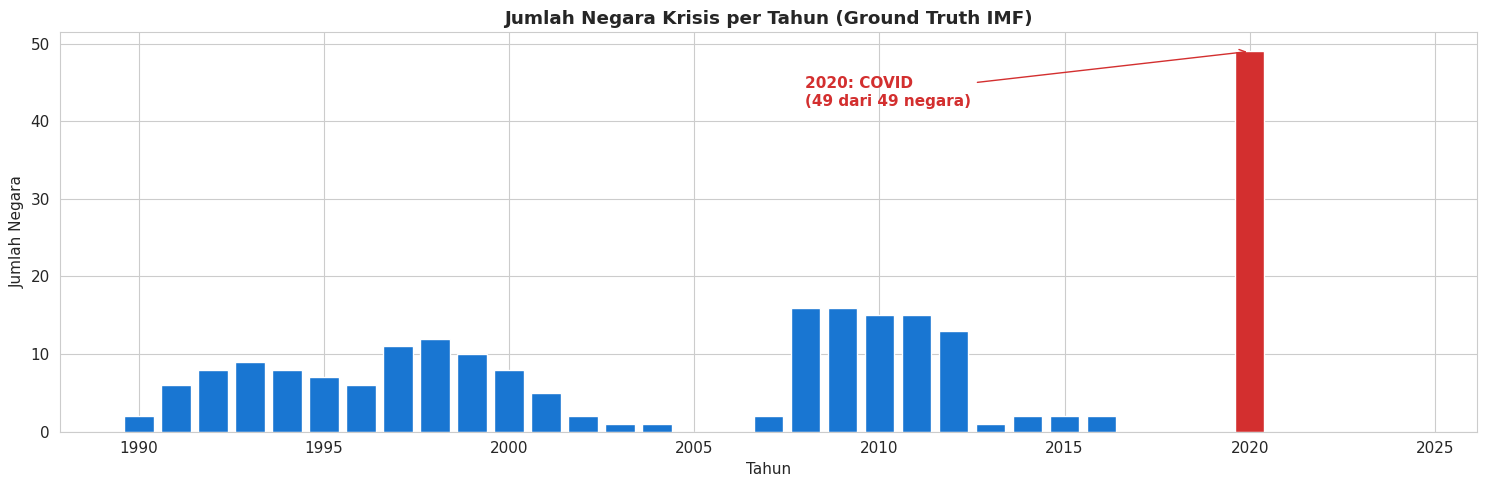

In [7]:
# TEMUAN PENTING: inkonsistensi pada ground truth tahun 2020.
# Tahun 2020 dilabeli krisis untuk SELURUH 49 negara, namun ketiga komponen
# (banking, currency, sovereign) bernilai 0. COVID-19 bukan systemic banking
# crisis menurut definisi Laeven dan Valencia.
y2020 = data[data['year'] == 2020]
print(f"Tahun 2020: {len(y2020)} baris, dilabeli krisis: {int(y2020['crisis_label'].sum())}")
print("Komponen krisis 2020:",
      y2020[['banking_crisis','currency_crisis','sovereign_debt_crisis']].sum().to_dict())
print("\nLabel 2020 berasal dari 'COVID-19 Global Shock', di luar taksonomi Laeven-Valencia.")
print("Analisis utama tetap memakai label ini apa adanya,")
print("namun disediakan uji sensitivitas tanpa 2020 pada Bagian 11.")

fig, ax = plt.subplots(figsize=(15,5))
yearly = data.groupby('year')['crisis_label'].sum()
colors = ['#d32f2f' if y==2020 else '#1976d2' for y in yearly.index]
ax.bar(yearly.index, yearly.values, color=colors)
ax.set_title('Jumlah Negara Krisis per Tahun (Ground Truth IMF)', fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Jumlah Negara')
ax.annotate('2020: COVID\n(49 dari 49 negara)', xy=(2020, 49), xytext=(2008, 42),
            arrowprops=dict(arrowstyle='->', color='#d32f2f'),
            color='#d32f2f', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Penskalaan: Country Demeaning dan Standardisasi Global

### Masalah pada versi lama

StandardScaler global membandingkan level struktural antar negara, bukan kondisi krisis:

- **Singapura** punya Trade per GDP di atas 300 persen sebagai hub perdagangan, sehingga selalu ekstrem dan dicap anomali 35 dari 35 tahun.
- **Spanyol** punya pengangguran struktural sekitar 15 sampai 20 persen, sehingga selalu tampak tinggi.
- **Jepang** saat krisis pengangguran naik dari 3 ke 6 persen, tetapi secara global masih tergolong rendah sehingga luput terdeteksi.

### Solusi

Setiap nilai dikurangi rata-rata negaranya sendiri, lalu distandarisasi secara global. Dengan cara ini setiap negara dibandingkan dengan kondisi normalnya sendiri, sementara skala antar fitur tetap sebanding. Pendekatan ini diuji empiris dan memberi AUC lebih baik dibanding penskalaan global murni, robust scaling, maupun z-score per negara.

In [8]:
# Bukti bias struktural pada penskalaan global murni
X_global = StandardScaler().fit_transform(data[FEATURE_COLS])
bias_check = data.assign(mean_abs_z=np.abs(X_global).mean(axis=1))
print("Negara dengan rata-rata |z| tertinggi (penskalaan GLOBAL):")
print(bias_check.groupby('economy')['mean_abs_z'].mean().nlargest(5).round(3).to_string())
print("\nSingapura dan Irlandia teratas. Ini struktur ekonomi terbuka, BUKAN krisis.")

Negara dengan rata-rata |z| tertinggi (penskalaan GLOBAL):
economy
SGP    1.532
CHN    1.051
IRL    0.937
BRA    0.888
MYS    0.784

Singapura dan Irlandia teratas. Ini struktur ekonomi terbuka, BUKAN krisis.


In [9]:
# Transformasi terpilih: country demeaning lalu standardisasi global
grp = data.groupby('economy')[FEATURE_COLS]
data_demeaned = data[FEATURE_COLS] - grp.transform('mean')

scaler = StandardScaler()
X = scaler.fit_transform(data_demeaned)
y_true = data['crisis_label'].values

print("Shape X:", X.shape)

bias_after = data.assign(mean_abs_z=np.abs(X).mean(axis=1))
print("\nRata-rata |z| tertinggi SETELAH demeaning:")
print(bias_after.groupby('economy')['mean_abs_z'].mean().nlargest(5).round(3).to_string())
print("\nDominasi Singapura hilang. Yang menonjol kini negara dengan gejolak nyata.")

Shape X: (1715, 14)

Rata-rata |z| tertinggi SETELAH demeaning:
economy
IRL    1.179
BRA    1.032
SAU    1.029
HUN    0.869
GRC    0.773

Dominasi Singapura hilang. Yang menonjol kini negara dengan gejolak nyata.


## 6. Pembagian Data: Semi-supervised Novelty Detection

Autoencoder dilatih **hanya pada data non-krisis**, lalu diuji pada seluruh data.

Dua hal penting untuk mencegah kebocoran data:

- Threshold dikalibrasi pada data latih normal saja, bukan seluruh dataset.
- Data uji berisi campuran normal dan krisis yang belum pernah dilihat model.

In [10]:
idx_normal = np.where(y_true == 0)[0]
idx_crisis = np.where(y_true == 1)[0]

# Split data normal: 70 persen train, 15 persen val, 15 persen test
idx_tr, idx_tmp = train_test_split(idx_normal, test_size=0.30, random_state=SEED)
idx_val, idx_te_norm = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)

X_train = X[idx_tr]
X_val   = X[idx_val]

# Test set berisi sisa data normal ditambah SELURUH data krisis
idx_test = np.concatenate([idx_te_norm, idx_crisis])
X_test   = X[idx_test]
y_test   = y_true[idx_test]

print(f"Train (normal saja) : {X_train.shape[0]:>4} obs")
print(f"Val   (normal saja) : {X_val.shape[0]:>4} obs")
print(f"Test  (campuran)    : {X_test.shape[0]:>4} obs  "
      f"({int(y_test.sum())} krisis / {int((y_test==0).sum())} normal)")
print("\n[OK] Tidak ada observasi krisis yang bocor ke data latih.")

Train (normal saja) : 1040 obs
Val   (normal saja) :  223 obs
Test  (campuran)    :  452 obs  (229 krisis / 223 normal)

[OK] Tidak ada observasi krisis yang bocor ke data latih.


## 7. Arsitektur Autoencoder

In [11]:
input_dim = X.shape[1]
BOTTLENECK = 6

# Kompatibilitas Keras 2 dan Keras 3.
# Keras 3 (dipakai Colab) mengganti argumen 'alpha' menjadi 'negative_slope'.
import inspect
_params = inspect.signature(LeakyReLU.__init__).parameters
LRELU = {'negative_slope': 0.1} if 'negative_slope' in _params else {'alpha': 0.1}
print("Argumen LeakyReLU:", list(LRELU.keys())[0])

inp = Input(shape=(input_dim,), name='input')

e = Dense(32, name='encoder_1')(inp)
e = BatchNormalization(name='bn_enc_1')(e)
e = LeakyReLU(**LRELU, name='lrelu_enc_1')(e)
e = Dropout(0.2, name='drop_enc_1')(e)

e = Dense(16, name='encoder_2')(e)
e = BatchNormalization(name='bn_enc_2')(e)
e = LeakyReLU(**LRELU, name='lrelu_enc_2')(e)
e = Dropout(0.2, name='drop_enc_2')(e)

btl = Dense(BOTTLENECK, activation='relu', name='bottleneck')(e)

d = Dense(16, name='decoder_1')(btl)
d = BatchNormalization(name='bn_dec_1')(d)
d = LeakyReLU(**LRELU, name='lrelu_dec_1')(d)
d = Dropout(0.2, name='drop_dec_1')(d)

d = Dense(32, name='decoder_2')(d)
d = BatchNormalization(name='bn_dec_2')(d)
d = LeakyReLU(**LRELU, name='lrelu_dec_2')(d)
d = Dropout(0.2, name='drop_dec_2')(d)

out = Dense(input_dim, activation='linear', name='output')(d)

autoencoder = Model(inp, out, name='Autoencoder_EWS')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print(f"Input: {input_dim} fitur, Bottleneck: {BOTTLENECK} dimensi "
      f"(kompresi {input_dim/BOTTLENECK:.1f}x)")
autoencoder.summary()

Argumen LeakyReLU: negative_slope
Input: 14 fitur, Bottleneck: 6 dimensi (kompresi 2.3x)


Model: "Autoencoder_EWS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_1 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_enc_1 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_2 (BatchNormalization)   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_enc_2 (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_1 (BatchNormalization)   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_dec_1 (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_dec_2 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,612 (10.20 KB)

 Trainable params: 2,420 (9.45 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Training

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = autoencoder.fit(
    X_train, X_train,
    epochs=200, batch_size=32, shuffle=True,
    validation_data=(X_val, X_val),
    callbacks=callbacks, verbose=1
)

print(f"\nSelesai pada epoch {len(history.history['loss'])}")
print(f"Train loss akhir: {history.history['loss'][-1]:.6f}")
print(f"Val   loss akhir: {history.history['val_loss'][-1]:.6f}")

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.5290 - val_loss: 0.7148 - learning_rate: 0.0010
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2013 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0762 - val_loss: 0.6704 - learning_rate: 0.0010
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0340 - val_loss: 0.6412 - learning_rate: 0.0010
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9657 - val_loss: 0.6173 - learning_rate: 0.0010
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9442 - val_loss: 0.5916 - learning_rate: 0.0010
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8950 - val_loss: 0.5622 - learning_rate: 0.0010
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8908 - val_loss: 0.5372 - learning_rate: 0.0010
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8347 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 10/200
33/33

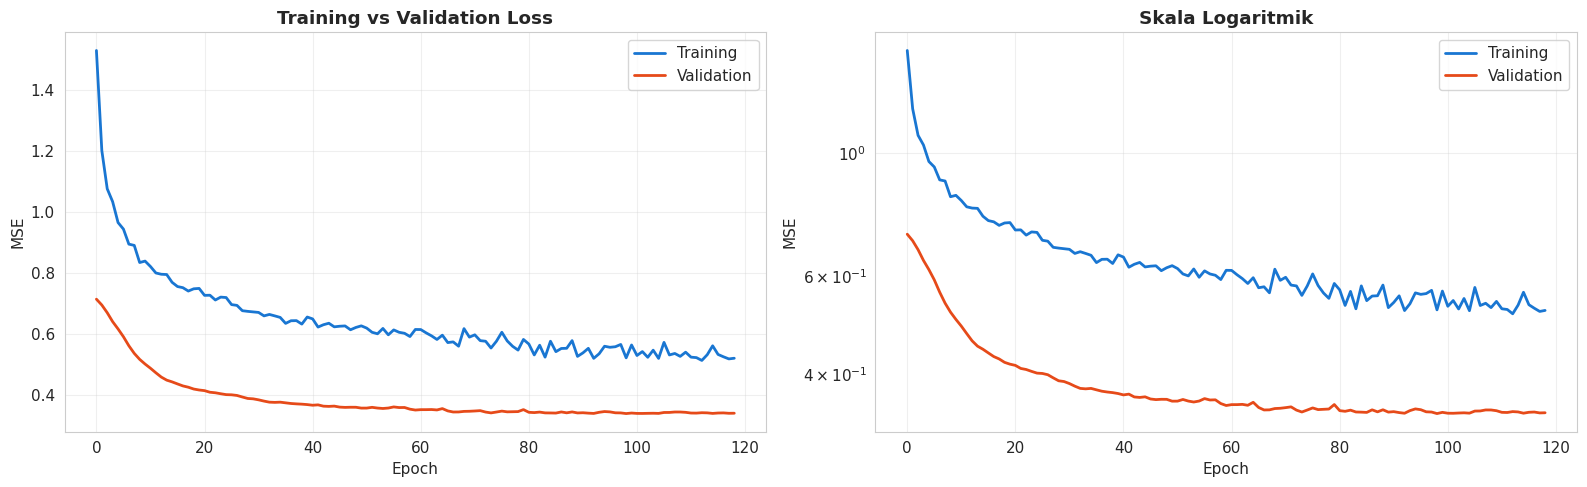

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
for ax, use_log in zip(axes, [False, True]):
    ax.plot(history.history['loss'], label='Training', color='#1976d2', lw=2)
    ax.plot(history.history['val_loss'], label='Validation', color='#e64a19', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    if use_log:
        ax.set_yscale('log'); ax.set_title('Skala Logaritmik', fontweight='bold')
    else:
        ax.set_title('Training vs Validation Loss', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Deteksi Anomali dan Kalibrasi Threshold

Threshold ditetapkan dari persentil ke-95 reconstruction error pada **data latih normal**. Ini penting: threshold tidak boleh dihitung dari seluruh dataset karena akan membocorkan informasi data uji.

In [14]:
def recon_error(model, Xa):
    Xh = model.predict(Xa, verbose=0)
    return np.mean(np.square(Xa - Xh), axis=1)

err_train = recon_error(autoencoder, X_train)
err_all   = recon_error(autoencoder, X)

# Threshold dikalibrasi HANYA pada data latih normal (anti-leakage)
PCT = 95
threshold = np.percentile(err_train, PCT)

data['reconstruction_error'] = err_all
data['anomaly_ae'] = (data['reconstruction_error'] > threshold).astype(int)

print(f"Threshold = persentil ke-{PCT} error data latih normal = {threshold:.6f}")
print(f"\nTerdeteksi anomali: {int(data['anomaly_ae'].sum())} "
      f"({data['anomaly_ae'].mean()*100:.1f} persen dari 1.715 observasi)")

Threshold = persentil ke-95 error data latih normal = 0.993319

Terdeteksi anomali: 117 (6.8 persen dari 1.715 observasi)


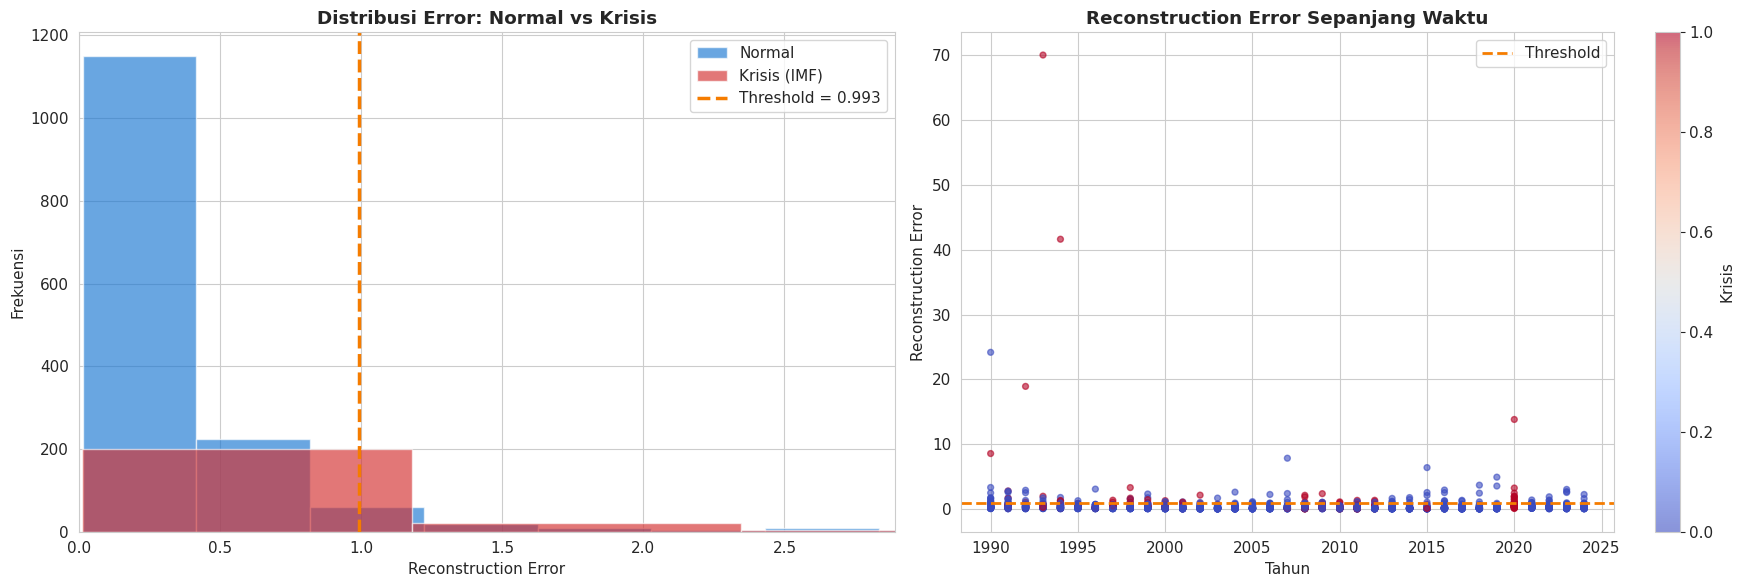

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

axes[0].hist(data.loc[data.crisis_label==0,'reconstruction_error'], bins=60,
             alpha=0.65, label='Normal', color='#1976d2')
axes[0].hist(data.loc[data.crisis_label==1,'reconstruction_error'], bins=60,
             alpha=0.65, label='Krisis (IMF)', color='#d32f2f')
axes[0].axvline(threshold, color='#f57c00', ls='--', lw=2.5,
                label=f'Threshold = {threshold:.3f}')
axes[0].set_xlabel('Reconstruction Error'); axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Error: Normal vs Krisis', fontweight='bold')
axes[0].legend(); axes[0].set_xlim(0, np.percentile(data.reconstruction_error, 99))

sc = axes[1].scatter(data['year'], data['reconstruction_error'],
                     c=data['crisis_label'], cmap='coolwarm', alpha=0.6, s=18)
axes[1].axhline(threshold, color='#f57c00', ls='--', lw=2, label='Threshold')
axes[1].set_xlabel('Tahun'); axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Error Sepanjang Waktu', fontweight='bold')
axes[1].legend(); plt.colorbar(sc, ax=axes[1], label='Krisis')
plt.tight_layout(); plt.show()

## 10. Evaluasi

Hasil dilaporkan pada dua cakupan:

1. **Seluruh data**, untuk perbandingan dengan lima algoritma lain dalam pipeline yang seragam.
2. **Data uji saja**, sebagai estimasi jujur karena model tidak pernah melihat data tersebut.

In [16]:
def evaluate(y, yhat, score, title):
    p = precision_score(y, yhat, zero_division=0)
    r = recall_score(y, yhat, zero_division=0)
    f = f1_score(y, yhat, zero_division=0)
    a = roc_auc_score(y, score) if len(np.unique(y)) > 1 else np.nan
    ap = average_precision_score(y, score) if len(np.unique(y)) > 1 else np.nan
    print("\n" + "="*58)
    print("  " + title)
    print("="*58)
    print(f"  Precision : {p:.4f}")
    print(f"  Recall    : {r:.4f}")
    print(f"  F1-Score  : {f:.4f}")
    print(f"  AUC-ROC   : {a:.4f}")
    print(f"  AUC-PR    : {ap:.4f}   (baseline = {y.mean():.4f})")
    # labels=[0,1] menjaga bentuk 2x2 walau hanya satu kelas yang diprediksi
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    return dict(precision=p, recall=r, f1=f, auc_roc=a, auc_pr=ap,
                tp=tp, fp=fp, fn=fn, tn=tn)

m_all = evaluate(y_true, data['anomaly_ae'].values,
                 data['reconstruction_error'].values,
                 'SELURUH DATA (1.715 obs) - untuk perbandingan antar model')

err_test  = err_all[idx_test]
pred_test = (err_test > threshold).astype(int)
m_test = evaluate(y_test, pred_test, err_test,
                  'DATA UJI SAJA - estimasi tanpa bias')


  SELURUH DATA (1.715 obs) - untuk perbandingan antar model
  Precision : 0.3675
  Recall    : 0.1878
  F1-Score  : 0.2486
  AUC-ROC   : 0.7196
  AUC-PR    : 0.2916   (baseline = 0.1335)
  TP=43  FP=74  FN=186  TN=1412

  DATA UJI SAJA - estimasi tanpa bias
  Precision : 0.7963
  Recall    : 0.1878
  F1-Score  : 0.3039
  AUC-ROC   : 0.7253
  AUC-PR    : 0.7077   (baseline = 0.5066)
  TP=43  FP=11  FN=186  TN=212


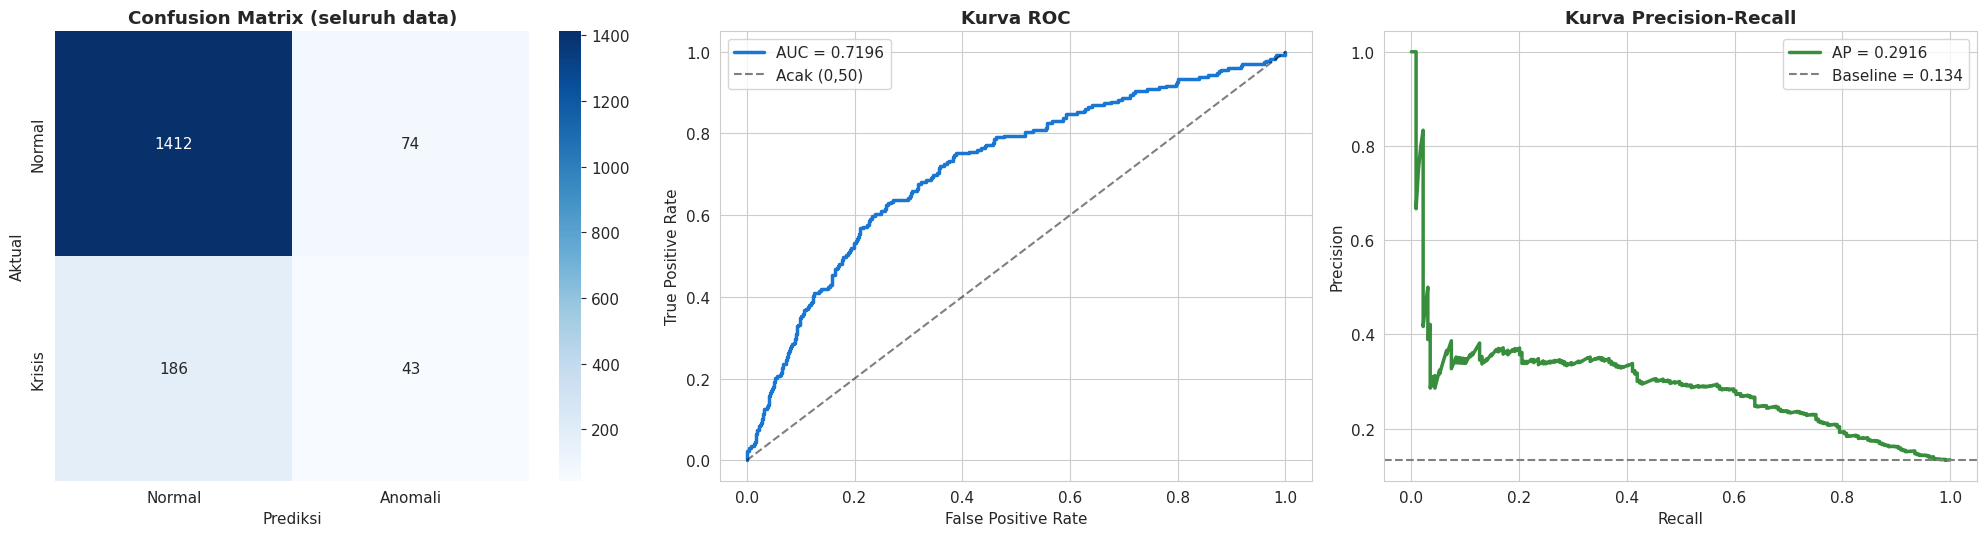

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20,5.5))

cm = confusion_matrix(y_true, data['anomaly_ae'], labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Krisis'])
axes[0].set_title('Confusion Matrix (seluruh data)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

fpr, tpr, _ = roc_curve(y_true, data['reconstruction_error'])
axes[1].plot(fpr, tpr, color='#1976d2', lw=2.5, label=f'AUC = {auc(fpr,tpr):.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Acak (0,50)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Kurva ROC', fontweight='bold'); axes[1].legend()

pr, rc, _ = precision_recall_curve(y_true, data['reconstruction_error'])
ap_val = average_precision_score(y_true, data['reconstruction_error'])
axes[2].plot(rc, pr, color='#388e3c', lw=2.5, label=f'AP = {ap_val:.4f}')
axes[2].axhline(y_true.mean(), ls='--', color='gray',
                label=f'Baseline = {y_true.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Kurva Precision-Recall', fontweight='bold'); axes[2].legend()

plt.tight_layout(); plt.show()

## 11. Uji Sensitivitas: Tanpa Tahun 2020

Tahun 2020 melabeli seluruh 49 negara sebagai krisis, padahal ketiga komponen Laeven-Valencia bernilai nol. Karena satu tahun itu menyumbang sekitar 21 persen dari total label krisis, perlu dicek apakah performa model bergantung pada COVID saja.

In [18]:
mask_no2020 = (data['year'] != 2020).values
m_no_covid = evaluate(y_true[mask_no2020],
                      data['anomaly_ae'].values[mask_no2020],
                      data['reconstruction_error'].values[mask_no2020],
                      'TANPA TAHUN 2020 - uji sensitivitas')

print(f"\nAUC dengan 2020 : {m_all['auc_roc']:.4f}")
print(f"AUC tanpa 2020  : {m_no_covid['auc_roc']:.4f}")
print(f"Selisih         : {m_all['auc_roc']-m_no_covid['auc_roc']:+.4f}")


  TANPA TAHUN 2020 - uji sensitivitas
  Precision : 0.3084
  Recall    : 0.1833
  F1-Score  : 0.2300
  AUC-ROC   : 0.6862
  AUC-PR    : 0.2246   (baseline = 0.1080)
  TP=33  FP=74  FN=147  TN=1412

AUC dengan 2020 : 0.7196
AUC tanpa 2020  : 0.6862
Selisih         : +0.0335


## 12. Evaluasi Early Warning: Sinyal pada t-1

Inti dari EWS adalah memberi peringatan **sebelum** krisis terjadi. Di sini diuji apakah reconstruction error pada tahun t-1 mampu memprediksi krisis pada tahun t.

Jika AUC lead mendekati 0,5 maka model bersifat *coincident*, yaitu mendeteksi krisis yang sedang berlangsung, bukan memberi peringatan dini. Temuan seperti itu harus dilaporkan apa adanya sebagai keterbatasan.

In [19]:
d = data.sort_values(['economy','year']).copy()
d['error_lag1'] = d.groupby('economy')['reconstruction_error'].shift(1)
d['error_lag2'] = d.groupby('economy')['reconstruction_error'].shift(2)

print(f"{'Horizon':<30}{'AUC-ROC':>10}")
print("-"*40)
auc_concurrent = roc_auc_score(y_true, data['reconstruction_error'])
print(f"{'Konkuren (t ke t)':<30}{auc_concurrent:>10.4f}")

lead_scores = {}
for lag, col in [(1,'error_lag1'), (2,'error_lag2')]:
    v = d.dropna(subset=[col])
    s = roc_auc_score(v['crisis_label'], v[col])
    lead_scores[lag] = s
    print(f"{f'Lead {lag} tahun (t-{lag} ke t)':<30}{s:>10.4f}")

print("\nInterpretasi:")
print("  AUC lead yang mendekati 0,50 berarti model bersifat COINCIDENT,")
print("  yaitu mendeteksi krisis yang sedang berlangsung, bukan early warning.")
print("  Temuan ini dilaporkan jujur sebagai keterbatasan penelitian.")

Horizon                          AUC-ROC
----------------------------------------
Konkuren (t ke t)                 0.7196
Lead 1 tahun (t-1 ke t)           0.6245
Lead 2 tahun (t-2 ke t)           0.5955

Interpretasi:
  AUC lead yang mendekati 0,50 berarti model bersifat COINCIDENT,
  yaitu mendeteksi krisis yang sedang berlangsung, bukan early warning.
  Temuan ini dilaporkan jujur sebagai keterbatasan penelitian.


## 13. Validasi terhadap Krisis Historis Besar

                   Episode  N  Terdeteksi  Detection Rate (%)  Mean Error
     Krisis Asia 1997-1998 10           5                50.0      1.0763
         Krisis Rusia 1998  1           1               100.0      1.0226
Krisis Argentina 2001-2002  2           1                50.0      1.3073
   Global Financial Crisis 98           7                 7.1      0.3756
        Krisis Utang Eropa 15           4                26.7      0.6504
                  COVID-19 49          10                20.4      1.0923


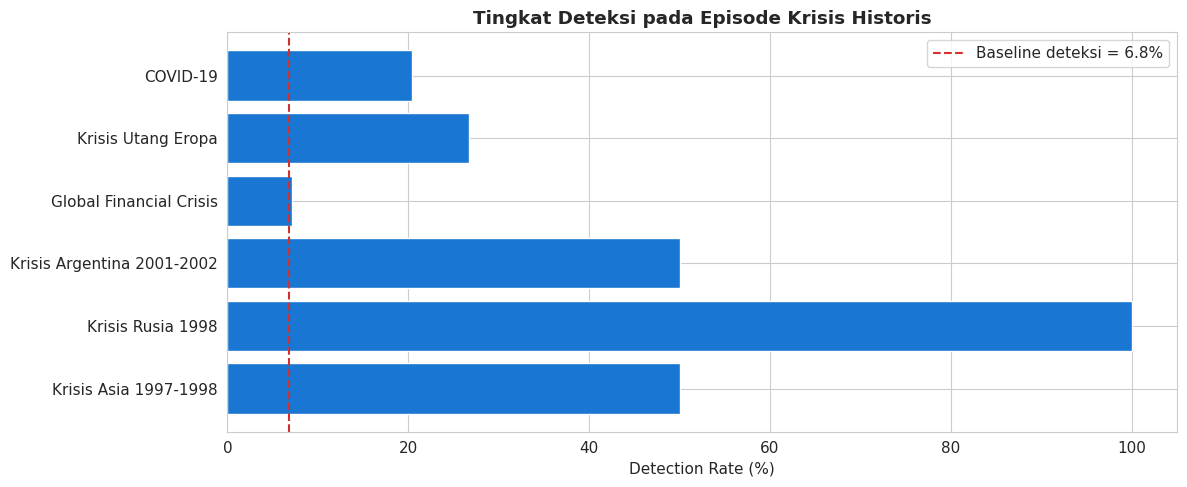

In [20]:
EPISODES = {
    'Krisis Asia 1997-1998'      : (1997, 1998, ['IDN','KOR','THA','MYS','PHL']),
    'Krisis Rusia 1998'          : (1998, 1998, ['RUS']),
    'Krisis Argentina 2001-2002' : (2001, 2002, ['ARG']),
    'Global Financial Crisis'    : (2008, 2009, None),
    'Krisis Utang Eropa'         : (2010, 2012, ['GRC','ESP','IRL','PRT','ITA']),
    'COVID-19'                   : (2020, 2020, None),
}

rows = []
for name, (y0, y1, ctry) in EPISODES.items():
    sub = data[(data.year >= y0) & (data.year <= y1)]
    if ctry:
        sub = sub[sub.economy.isin(ctry)]
    if len(sub) == 0:
        continue
    rows.append({'Episode': name, 'N': len(sub),
                 'Terdeteksi': int(sub.anomaly_ae.sum()),
                 'Detection Rate (%)': round(sub.anomaly_ae.mean()*100, 1),
                 'Mean Error': round(sub.reconstruction_error.mean(), 4)})

ep = pd.DataFrame(rows)
print(ep.to_string(index=False))

fig, ax = plt.subplots(figsize=(12,5))
ax.barh(ep['Episode'], ep['Detection Rate (%)'], color='#1976d2')
ax.axvline(data.anomaly_ae.mean()*100, ls='--', color='#d32f2f',
           label=f'Baseline deteksi = {data.anomaly_ae.mean()*100:.1f}%')
ax.set_xlabel('Detection Rate (%)')
ax.set_title('Tingkat Deteksi pada Episode Krisis Historis', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 14. Interpretasi: Fitur Pendorong Anomali

Kontribusi fitur terhadap deteksi krisis:
                feature  err_crisis  err_normal  difference
  Exchange_Depreciation      6.1930      0.1882      6.0048
             GDP_Growth      2.3163      0.5839      1.7324
     Broad_Money_Growth      1.4880      0.1428      1.3452
        FDI_Inflows_GDP      1.5444      0.6768      0.8677
    Domestic_Credit_GDP      1.0479      0.4076      0.6403
          Inflation_CPI      0.7401      0.1987      0.5413
      Gross_Savings_GDP      0.7502      0.3146      0.4356
    Manufacturing_Value      0.7182      0.3951      0.3231
    Current_Account_GDP      0.7034      0.3939      0.3095
Reserves_Months_Imports      0.7656      0.5110      0.2546
           Unemployment      0.6980      0.5203      0.1777
         Investment_GDP      0.3821      0.2830      0.0991
            Exports_GDP      0.2137      0.1546      0.0591
            Imports_GDP      0.2702      0.2177      0.0525


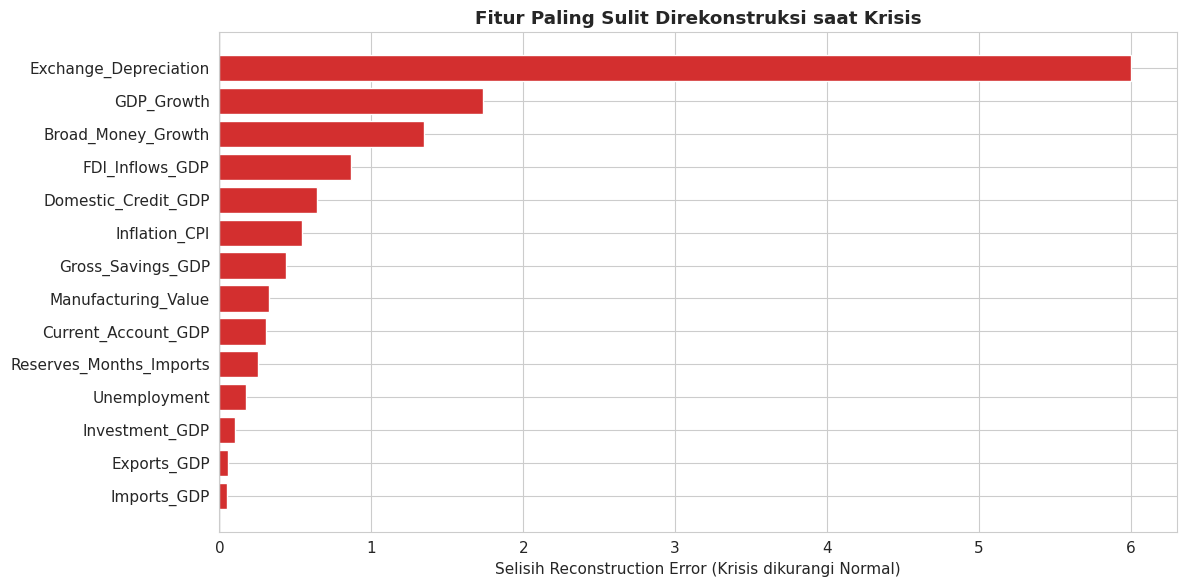

In [21]:
X_hat = autoencoder.predict(X, verbose=0)
per_feat_err = np.square(X - X_hat)

imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'err_crisis': per_feat_err[y_true==1].mean(axis=0),
    'err_normal': per_feat_err[y_true==0].mean(axis=0),
})
imp['difference'] = imp['err_crisis'] - imp['err_normal']
imp = imp.sort_values('difference', ascending=False)

print("Kontribusi fitur terhadap deteksi krisis:")
print(imp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12,6))
colors = ['#d32f2f' if v>0 else '#1976d2' for v in imp['difference']]
ax.barh(imp['feature'], imp['difference'], color=colors)
ax.set_xlabel('Selisih Reconstruction Error (Krisis dikurangi Normal)')
ax.set_title('Fitur Paling Sulit Direkonstruksi saat Krisis', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 15. Ekspor Hasil (Format Standar Kelompok)

Format wajib: kolom economy, year, anomaly_score, predicted_anomaly. Urut berdasarkan economy lalu year, tepat 1.715 baris.

In [22]:
# Pengaman: jika Bagian 12 belum dijalankan, isi nilai kosong agar sel ini tetap jalan
try:
    lead_scores
except NameError:
    lead_scores = {}

hasil = data[['economy','year','reconstruction_error','anomaly_ae']].copy()
hasil = hasil.rename(columns={'reconstruction_error':'anomaly_score',
                              'anomaly_ae':'predicted_anomaly'})
hasil = hasil.sort_values(['economy','year']).reset_index(drop=True)

assert len(hasil) == 1715
assert list(hasil.columns) == ['economy','year','anomaly_score','predicted_anomaly']
assert set(hasil['predicted_anomaly'].unique()) <= {0,1}

hasil.to_csv('hasil_autoencoder.csv', index=False)
print("[OK] hasil_autoencoder.csv - 1.715 baris, urut economy dan year")
print(hasil.head())

ringkasan = pd.DataFrame([{
    'model': 'Autoencoder',
    'paradigma': 'Semi-supervised Novelty Detection (Deep Learning)',
    'n_obs': len(data),
    'n_features': len(FEATURE_COLS),
    'threshold': threshold,
    'n_anomali': int(data['anomaly_ae'].sum()),
    'precision': m_all['precision'], 'recall': m_all['recall'],
    'f1_score': m_all['f1'], 'auc_roc': m_all['auc_roc'], 'auc_pr': m_all['auc_pr'],
    'auc_roc_test': m_test['auc_roc'],
    'auc_roc_tanpa2020': m_no_covid['auc_roc'],
    'auc_lead1': lead_scores.get(1), 'auc_lead2': lead_scores.get(2),
    'seed': SEED,
}])
ringkasan.to_csv('ringkasan_model_autoencoder.csv', index=False)
print("\n[OK] ringkasan_model_autoencoder.csv")
ringkasan.T

[OK] hasil_autoencoder.csv - 1.715 baris, urut economy dan year
  economy  year  anomaly_score  predicted_anomaly
0     ARE  1990       1.494827                  1
1     ARE  1991       0.252084                  0
2     ARE  1992       0.199848                  0
3     ARE  1993       0.229431                  0
4     ARE  1994       0.215683                  0

[OK] ringkasan_model_autoencoder.csv


,0
model,Autoencoder
paradigma,Semi-supervised Novelty Detection (Deep Learning)
n_obs,1715
n_features,14
threshold,0.993319
n_anomali,117
precision,0.367521
recall,0.187773
f1_score,0.248555
auc_roc,0.719648


In [23]:
# Simpan juga dataset berfitur agar bisa dipakai anggota lain
data.to_csv('data_features_autoencoder.csv', index=False)
print("[OK] data_features_autoencoder.csv (fitur dan label, 1.715 baris)")

print("")
print("="*62)
print("  RINGKASAN AKHIR - AUTOENCODER (REVISI)")
print("="*62)
print(f"  Observasi        : {len(data):,} (49 negara x 35 tahun)")
print(f"  Fitur            : {len(FEATURE_COLS)} (memakai Exchange_Depreciation)")
print(f"  Ground truth     : IMF Laeven-Valencia, {int(y_true.sum())} krisis "
      f"({y_true.mean()*100:.1f} persen)")
print(f"  Penskalaan       : Country demeaning + StandardScaler")
print(f"  Skema latih      : Semi-supervised (train hanya data normal)")
print(f"  Threshold        : P{PCT} error data latih = {threshold:.6f}")
print(f"  Seed             : {SEED}")
print("-"*62)
print(f"  Precision        : {m_all['precision']:.4f}")
print(f"  Recall           : {m_all['recall']:.4f}")
print(f"  F1-Score         : {m_all['f1']:.4f}")
print(f"  AUC-ROC (semua)  : {m_all['auc_roc']:.4f}")
print(f"  AUC-ROC (uji)    : {m_test['auc_roc']:.4f}")
print(f"  AUC-ROC (no2020) : {m_no_covid['auc_roc']:.4f}")
_l1 = lead_scores.get(1)
print(f"  AUC-ROC (lead 1) : {_l1:.4f}" if _l1 is not None
      else "  AUC-ROC (lead 1) : belum dihitung (jalankan Bagian 12)")
print("="*62)

[OK] data_features_autoencoder.csv (fitur dan label, 1.715 baris)

  RINGKASAN AKHIR - AUTOENCODER (REVISI)
  Observasi        : 1,715 (49 negara x 35 tahun)
  Fitur            : 14 (memakai Exchange_Depreciation)
  Ground truth     : IMF Laeven-Valencia, 229 krisis (13.4 persen)
  Penskalaan       : Country demeaning + StandardScaler
  Skema latih      : Semi-supervised (train hanya data normal)
  Threshold        : P95 error data latih = 0.993319
  Seed             : 42
--------------------------------------------------------------
  Precision        : 0.3675
  Recall           : 0.1878
  F1-Score         : 0.2486
  AUC-ROC (semua)  : 0.7196
  AUC-ROC (uji)    : 0.7253
  AUC-ROC (no2020) : 0.6862
  AUC-ROC (lead 1) : 0.6245
